In [7]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgr_df = pickle.load(open('C:/Users/ejeme/Documents/python_repos/SGR/vgg16_cifar10/sgr_set','rb'))
sgr_df = sgr_df.sample(frac=1, random_state=42)

In [3]:
train_set = sgr_df.iloc[:5000]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[5000:]

In [21]:
delta = 0.001

desired_risks = [i/100 for i in range(1,15)]
results = []

for target_r in desired_risks:
    
    sgr_dico = SGR(delta, target_r, train_set)
    theta_star = sgr_dico['theta_star']
    covered_test_set = test_set.loc[test_set.SR > theta_star]

    results.append({'desired_risk' : target_r,
                    'risk_bound' : sgr_dico['b_star'],
                    'train_risk' : sgr_dico['risk'],
                    'train_coverage' : sgr_dico['coverage'],
                    'test_risk' : (covered_test_set.y_true != covered_test_set.y_pred).sum()/covered_test_set.shape[0],
                    'test_coverage' : covered_test_set.shape[0]/test_set.shape[0]})

In [22]:
results = pd.DataFrame(results)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.01,0.015762,0.004003,0.2498,0.001609,0.2486
1,0.02,0.020477,0.008899,0.3596,0.005679,0.3522
2,0.03,0.029877,0.017801,0.5056,0.013660,0.4978
3,0.04,0.039871,0.026843,0.5886,0.025009,0.5838
4,0.05,0.049927,0.036305,0.6776,0.037313,0.6700
5,0.06,0.060303,0.045889,0.7322,0.047658,0.7260
6,0.07,0.070038,0.054873,0.7654,0.055174,0.7576
7,0.08,0.080200,0.064428,0.8040,0.064234,0.8002
8,0.09,0.090424,0.074056,0.8372,0.076281,0.8390
9,0.10,0.100098,0.083237,0.8674,0.086499,0.8740


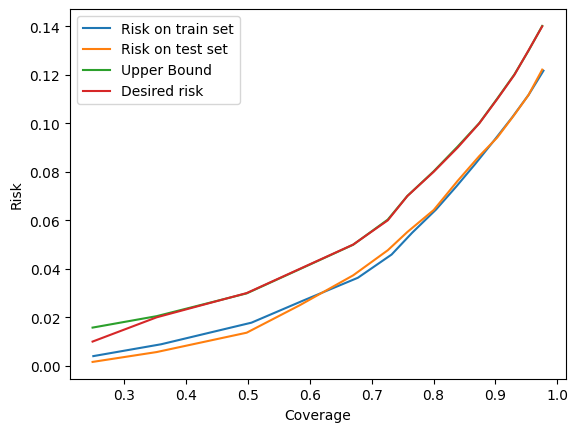

In [23]:
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on train set')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.plot(results.test_coverage, results.risk_bound, label = 'Upper Bound')
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.legend()
plt.show()